<a href="https://colab.research.google.com/github/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Assignment-5/Assignment-5_SomeComments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chemical Applications of Machine Learning (CHEM 4930/5610) - Spring 2026

### Assignment 5 - Deadline 4/6/2026
Points 10

#### General Comments
All figures and graph should have approriate labels on the two axis, and should include a legend with appropriate labels of the different plots.

The notebook should be return in working format. That is, I should be able to reset all the output and re-run all the cells and get the same results as you obtained.

**You should start by saving a copy of the notebook to your Google Drive so you preserve all changes.**

**Please add your name as a suffix to the filname**

**Student Name**: Add your name here

**AI usage statement:**
Here you should give a statement about any usage of AI tools to assist you with the coding.

### Task 1 - 10 points

Here we consider a alanine dipeptide in vacuum that is simple model often used to test methods. It consists of one alanine (Ala) residues and capping group. It is conformational dynamics can be understood in terms of the backbone dihedral angles $\Phi$ and $\Psi$.

![Alanine Dipeptide](https://github.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Assignment-5/AlanineDipeptideVac-1.png?raw=true)

The free energy landscape/surface $F(\Phi,\Psi)$ (see figure above) as function of $\Phi$ and $\Psi$ is known as the [Ramachandran plot](https://en.wikipedia.org/wiki/Ramachandran_plot). Note that here we are considering the system in vacuum so the energy landscape is different from what one would expect in solvent.

This system has two states, $C_{7\mathrm{eq}}$ and $C_{7\mathrm{ax}}$, where the $C_{7\mathrm{eq}}$ state is more populated one (i.e., lower in free energy).

Note that free energy landscape/surface $F(\Phi,\Psi)$ is related to the probability density function $P(\Phi,\Psi)$ through the following equation:

$$
F(\Phi,\Psi) = -k_{\mathrm{B}} T \ln P(\Phi,\Psi) + C
$$

where $T$ is the temperature, $k_{\mathrm{B}}$ is the Boltzmann constant, so that $k_{\mathrm{B}} T$ is the thermal energy, and $C$ is an unimportant constant. We also have that

$$
P(\Phi,\Psi) \propto \exp[-\beta F(\Phi,\Psi) ]
$$

where $\beta = (k_{\mathrm{B}} T)^{-1}$ is the inverse of the thermal energy.

We will consider dataset from molecular dynamics simulations, in particular parallel tempering (PT) simulations, that should give correct equilibrium sampling according to the Boltzmann distribution.

The dataset we consider is at temperture of 576 K. It is from a 100 ns PT simulations where we save variables every 10 ps, so we have 10000 samples.

The dataset is composed of two files. The `AlanineDipeptide_T-576K_Dihedrals.data` file includes the dihedral angles, $\Phi$, $\Psi$, $\Theta$. The `AlanineDipeptide_T-576K_HeavyAtomDistances.data` file includes all possible pairs of heavy atom distances (there are 10 heavy atoms, so the number of all possible pairs is $(10\cdot 9)/2 = 45$).

#### A)
Visualize the dataset in terms of the backbone dihedral angles $\Phi$ and $\Psi$. You should look at the timeseries and a 2D scatter plots.

You should estimate and visualize the 1D probability density for $\Phi$ and $\Psi$, and also the 2D probability density for $\Phi$ and $\Psi$.

Optional: You will get 1 extra point if you correctly handle the periodicity of the dihedral angles when estimating the 1D and 2D probability densities.

#### B)
Design criteria so that you can assign each sample from the dataset to either the $C_{7\mathrm{eq}}$ or the $C_{7\mathrm{ax}}$ state. You should use this later on to check if the embedding that you obtain correctly seperate the two differnet states.

Note: This criteria should be more advanced than what we did in Lecture 16 where we only considered if $\Phi$ was postive.

#### C)
Perform Principal Component Analysis (PCA) for the system using all heavy atom distances as input features, and visualize the first two principle components.

Here, you should use the full dataset in the analysis (all 10000 samples).

How much of the variance is described by the first two principle components?

Use the results from B) to understand if the PCA embeddings is able to seperate the $C_{7\mathrm{eq}}$ and $C_{7\mathrm{ax}}$ states.

You should try both using unscaled and scaled distances as input features. How does this affect the results.

#### D)
Some of the heavy atom distances might not be relevant and only add noise. To address this, design criteria for filtering out distances that might not be relevant and re-do the PCA analysis. How does this affect the results?

For example, you might consider only using distances that have standard deviation above some given threshold value.

#### E)
Perform *t*-SNE analysis using the [openTSNE](https://opentsne.readthedocs.io/en/stable/index.html) code and obtain two-dimensional embeddings.

One feature of the openTNSE implementation of *t*-SNE, as compared to the scikit-learn one, is that it allows for embedding new samples into existing embeddings.

Here, you should use 10% of the dataset (1000 samples) to fit the $t$-SNE embedding (for example by taking only every 10 sample), and then transform the full dataset and plot and visulize that.

Here, you should use the set of filtered distances that you used in D). I would also recommend to use scaled distances.

Here, you should consider different perplexity values in the analysis. What is optimal perplexity value in your opinion?

Once you have found the optimal perplexity value, you can you try to use the full dataset in the fitting of the $t$-SNE embedding. The openTNSE implementation should more performant thant the scikit-learn one. Does this affect the results in some manner.

#### F) - Optional for 2 point
For the *t*-SNE analysis, using the the optimal perplexity value, test the effect of 1) using either unscaled or scaled features; and 2) using either the filtered distances or the full set of 45 distances.

In [1]:
# Download datasets

%%bash
datasets="
AlanineDipeptide_T-576K_Dihedrals.data
AlanineDipeptide_T-576K_HeavyAtomDistances.data
"

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Assignment-5/Datasets"

for d in ${datasets}
do
  wget ${url}/${d} &> /dev/null
done

ls

AlanineDipeptide_T-576K_Dihedrals.data
AlanineDipeptide_T-576K_HeavyAtomDistances.data
sample_data


In [11]:
# basic
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
!head AlanineDipeptide_T-576K_HeavyAtomDistances.data

#! FIELDS time d_ace-1-ch3_ace-1-c d_ace-1-ch3_ace-1-o d_ace-1-ch3_ala-2-n d_ace-1-ch3_ala-2-ca d_ace-1-ch3_ala-2-cb d_ace-1-ch3_ala-2-c d_ace-1-ch3_ala-2-o d_ace-1-ch3_nme-3-n d_ace-1-ch3_nme-3-ch3 d_ace-1-c_ace-1-o d_ace-1-c_ala-2-n d_ace-1-c_ala-2-ca d_ace-1-c_ala-2-cb d_ace-1-c_ala-2-c d_ace-1-c_ala-2-o d_ace-1-c_nme-3-n d_ace-1-c_nme-3-ch3 d_ace-1-o_ala-2-n d_ace-1-o_ala-2-ca d_ace-1-o_ala-2-cb d_ace-1-o_ala-2-c d_ace-1-o_ala-2-o d_ace-1-o_nme-3-n d_ace-1-o_nme-3-ch3 d_ala-2-n_ala-2-ca d_ala-2-n_ala-2-cb d_ala-2-n_ala-2-c d_ala-2-n_ala-2-o d_ala-2-n_nme-3-n d_ala-2-n_nme-3-ch3 d_ala-2-ca_ala-2-cb d_ala-2-ca_ala-2-c d_ala-2-ca_ala-2-o d_ala-2-ca_nme-3-n d_ala-2-ca_nme-3-ch3 d_ala-2-cb_ala-2-c d_ala-2-cb_ala-2-o d_ala-2-cb_nme-3-n d_ala-2-cb_nme-3-ch3 d_ala-2-c_ala-2-o d_ala-2-c_nme-3-n d_ala-2-c_nme-3-ch3 d_ala-2-o_nme-3-n d_ala-2-o_nme-3-ch3 d_nme-3-n_nme-3-ch3
 0.000000 0.149772 0.233943 0.245166 0.385790 0.482077 0.461674 0.566019 0.449139 0.557654 0.125140 0.132596 0.249862 0.3

In [12]:
def get_variables_names_from_header(filename):
  with open(filename, 'r') as f:
    header = f.readline()
    variables = header.split()[2:]
  return variables

In [15]:
dist_variables = get_variables_names_from_header("AlanineDipeptide_T-576K_HeavyAtomDistances.data")

In [14]:
data_dist = pd.read_csv("AlanineDipeptide_T-576K_HeavyAtomDistances.data", header=None, names=dist_variables, sep="\\s+", comment="#")

# only take every N-th value
stride = 1
data_dist = data_dist.iloc[::stride]
# this is to reset the index
data_dist.reset_index(drop=True, inplace=True)

In [17]:
data_dist.keys()

Index(['time', 'd_ace-1-ch3_ace-1-c', 'd_ace-1-ch3_ace-1-o',
       'd_ace-1-ch3_ala-2-n', 'd_ace-1-ch3_ala-2-ca', 'd_ace-1-ch3_ala-2-cb',
       'd_ace-1-ch3_ala-2-c', 'd_ace-1-ch3_ala-2-o', 'd_ace-1-ch3_nme-3-n',
       'd_ace-1-ch3_nme-3-ch3', 'd_ace-1-c_ace-1-o', 'd_ace-1-c_ala-2-n',
       'd_ace-1-c_ala-2-ca', 'd_ace-1-c_ala-2-cb', 'd_ace-1-c_ala-2-c',
       'd_ace-1-c_ala-2-o', 'd_ace-1-c_nme-3-n', 'd_ace-1-c_nme-3-ch3',
       'd_ace-1-o_ala-2-n', 'd_ace-1-o_ala-2-ca', 'd_ace-1-o_ala-2-cb',
       'd_ace-1-o_ala-2-c', 'd_ace-1-o_ala-2-o', 'd_ace-1-o_nme-3-n',
       'd_ace-1-o_nme-3-ch3', 'd_ala-2-n_ala-2-ca', 'd_ala-2-n_ala-2-cb',
       'd_ala-2-n_ala-2-c', 'd_ala-2-n_ala-2-o', 'd_ala-2-n_nme-3-n',
       'd_ala-2-n_nme-3-ch3', 'd_ala-2-ca_ala-2-cb', 'd_ala-2-ca_ala-2-c',
       'd_ala-2-ca_ala-2-o', 'd_ala-2-ca_nme-3-n', 'd_ala-2-ca_nme-3-ch3',
       'd_ala-2-cb_ala-2-c', 'd_ala-2-cb_ala-2-o', 'd_ala-2-cb_nme-3-n',
       'd_ala-2-cb_nme-3-ch3', 'd_ala-2-c_ala-2-o', 'd_ala

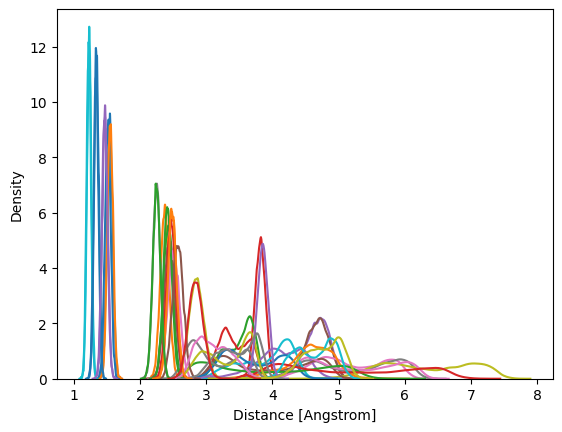

In [21]:
for d in dist_variables[1:]:
  sns.kdeplot(data_dist[d]*10,bw_adjust=0.6)
  plt.xlabel("Distance [Angstrom]")
  plt.ylabel("Density")
plt.show()

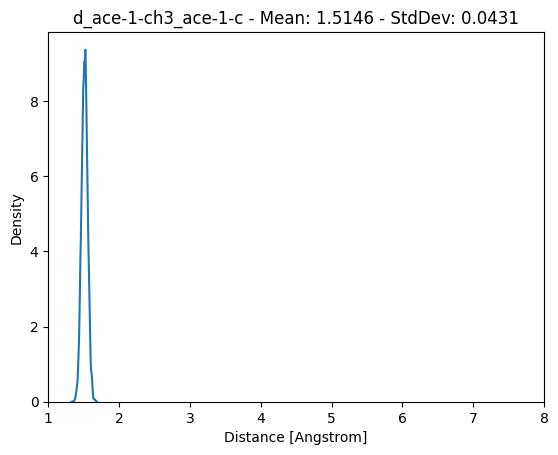

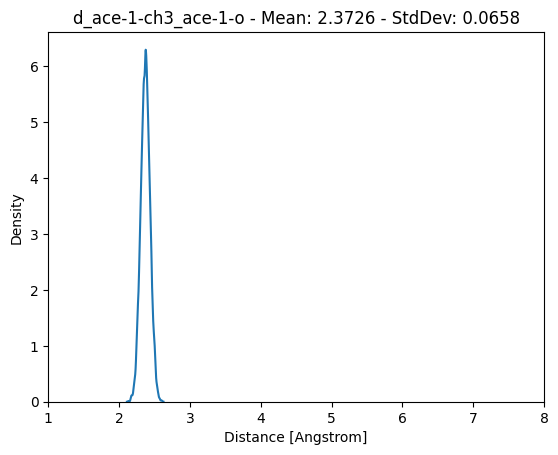

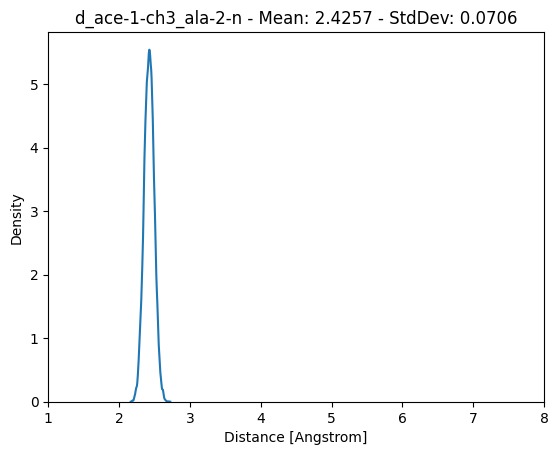

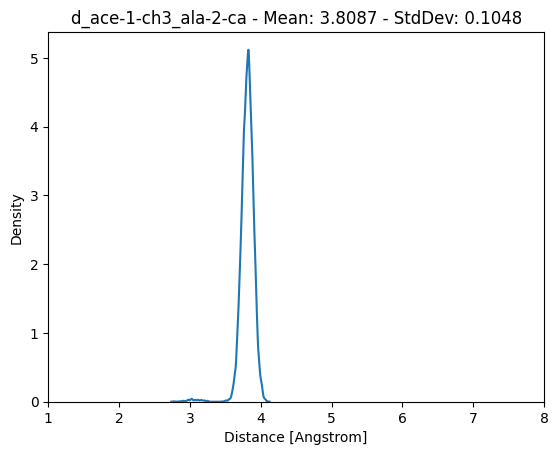

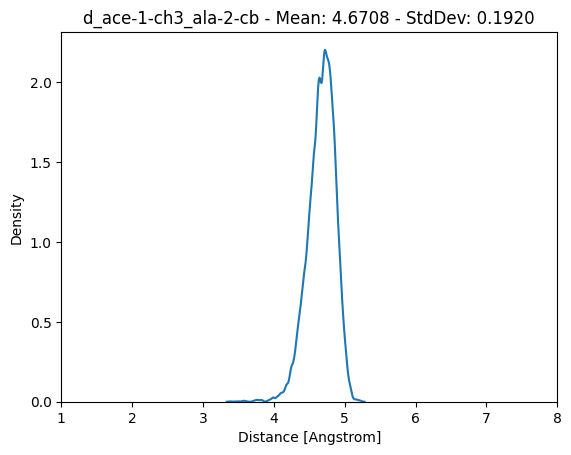

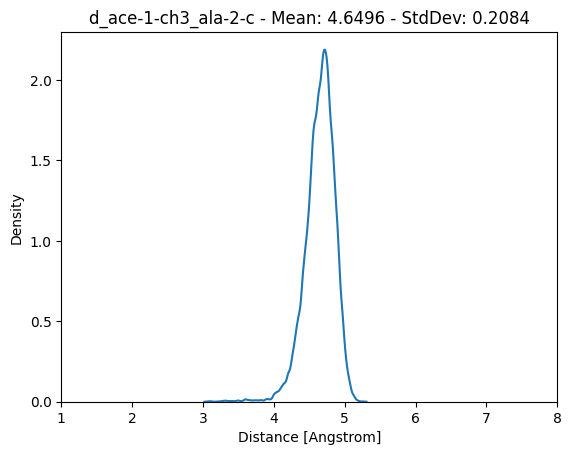

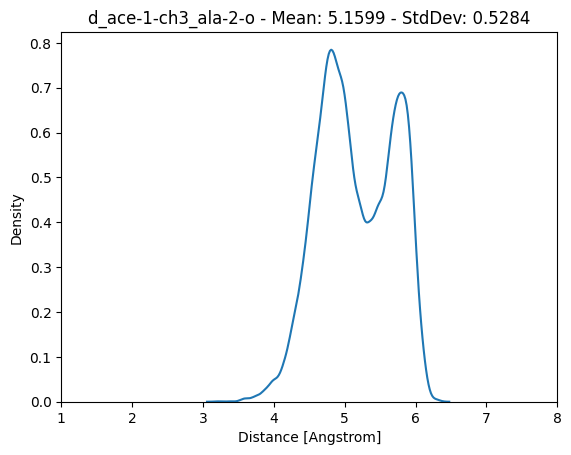

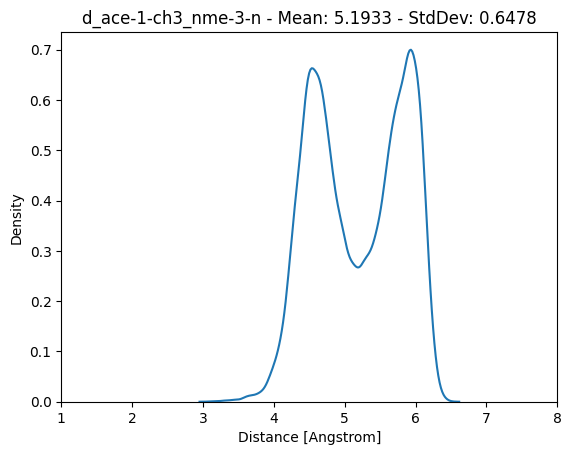

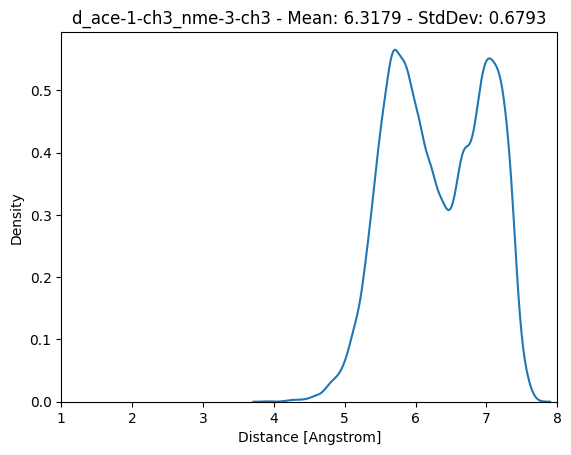

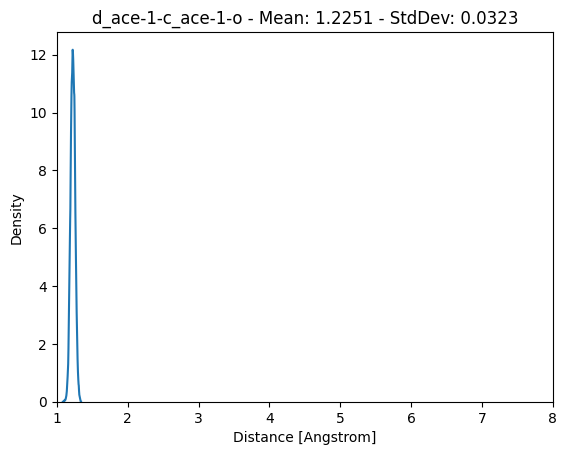

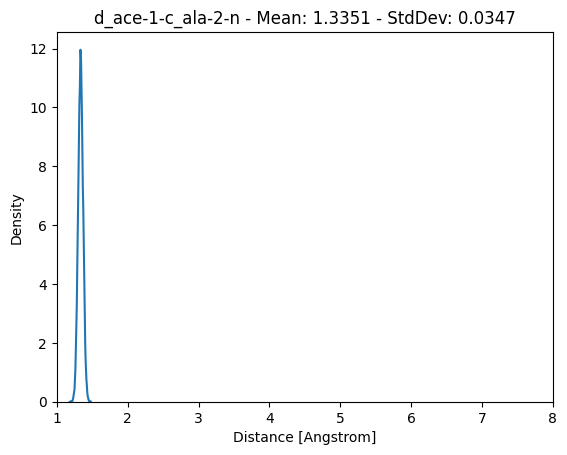

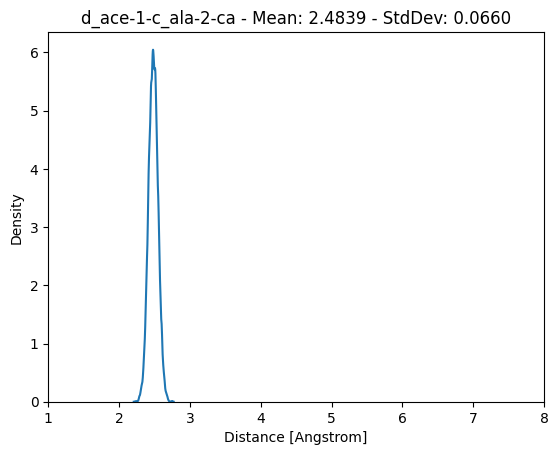

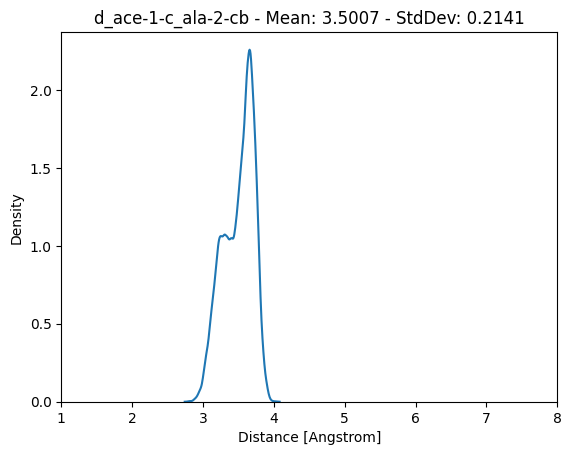

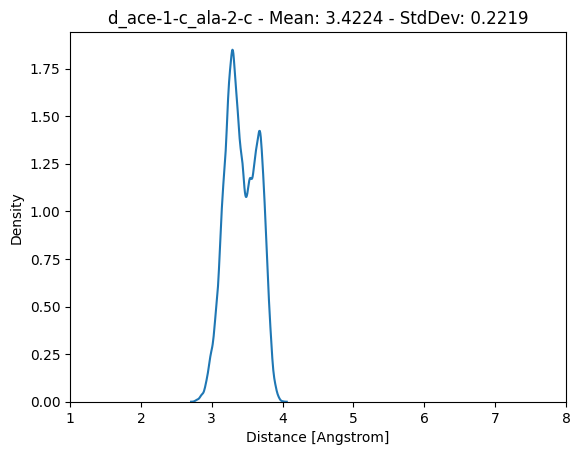

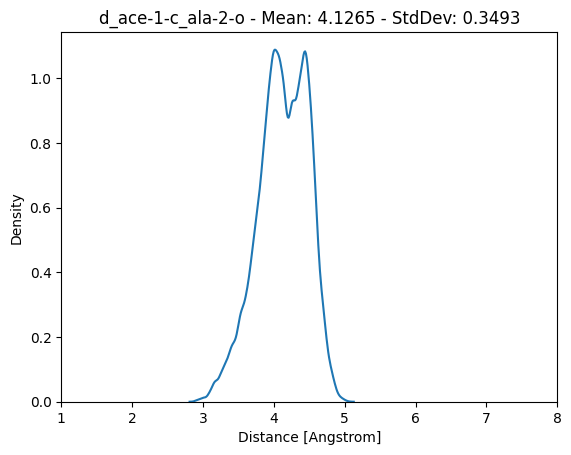

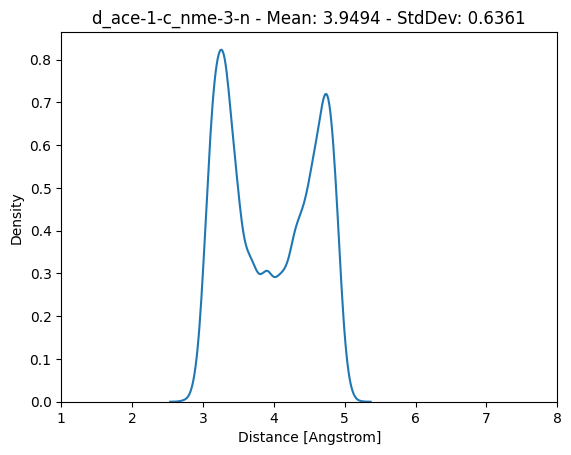

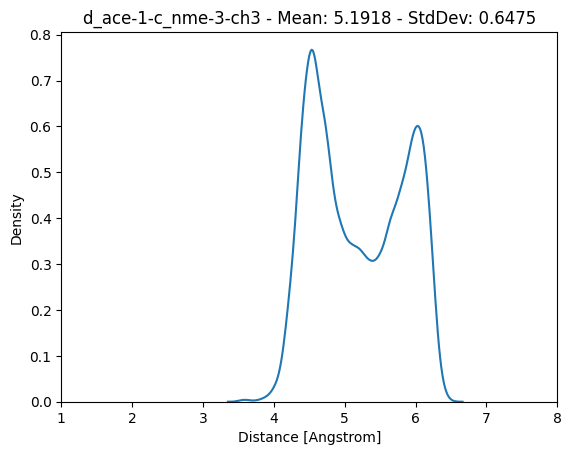

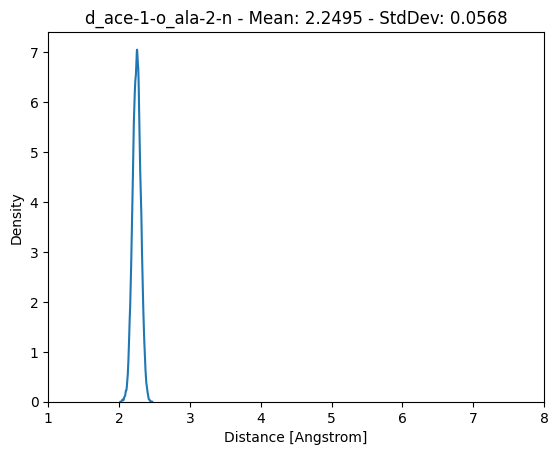

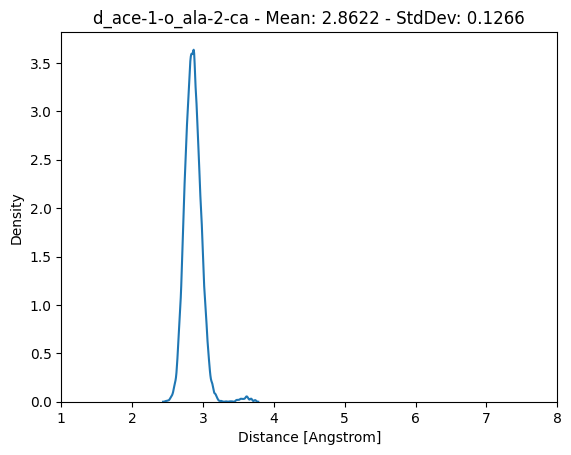

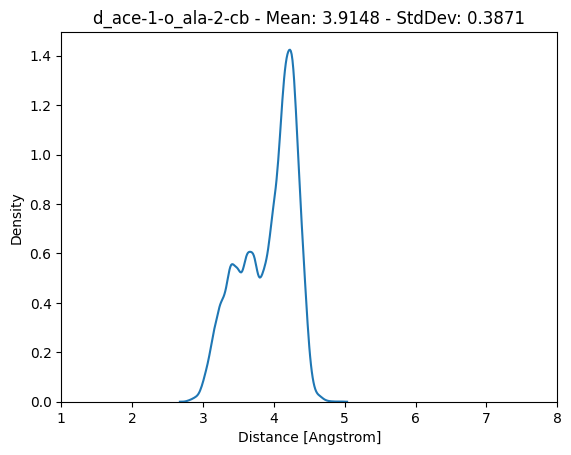

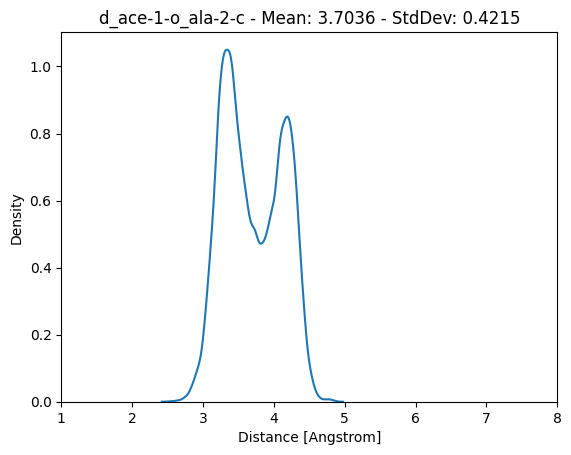

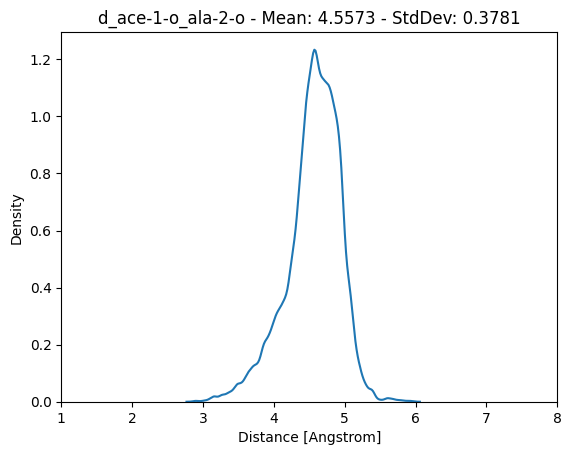

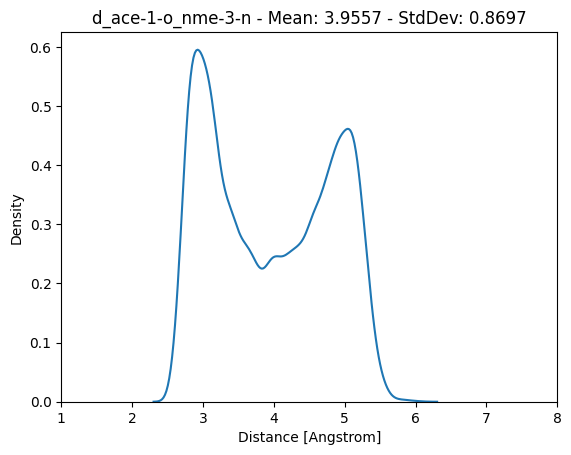

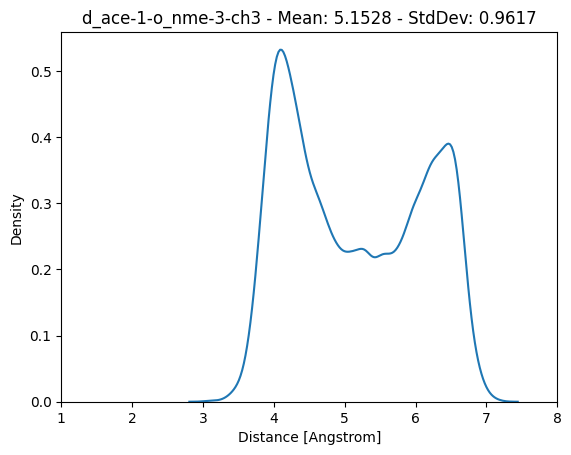

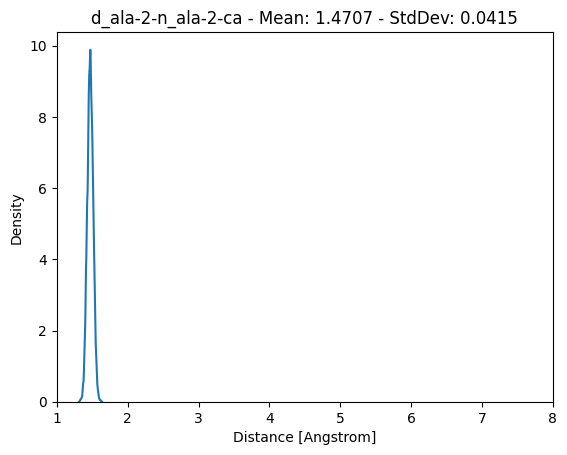

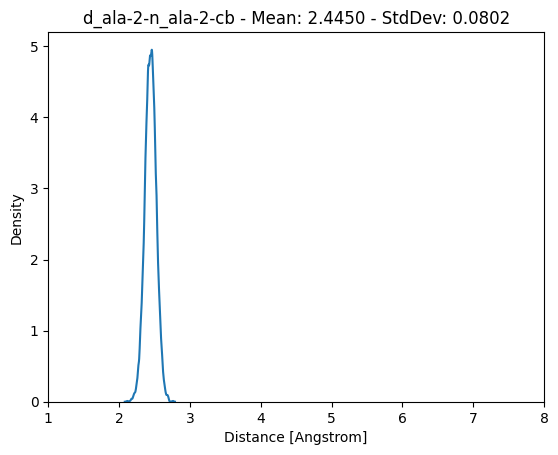

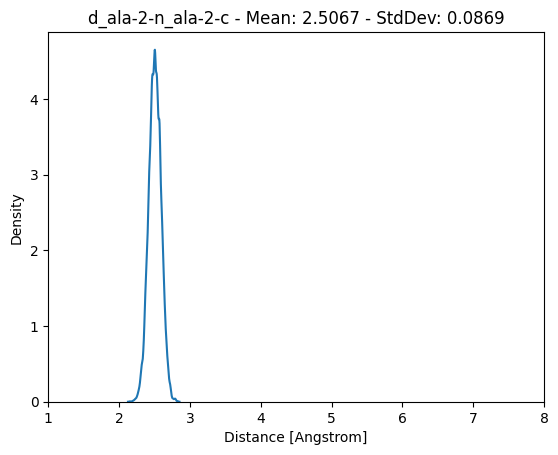

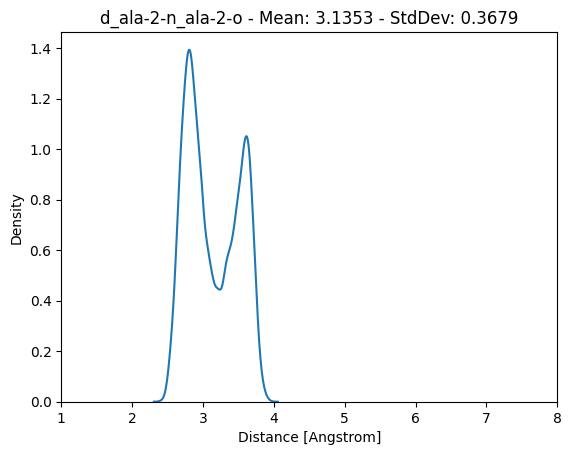

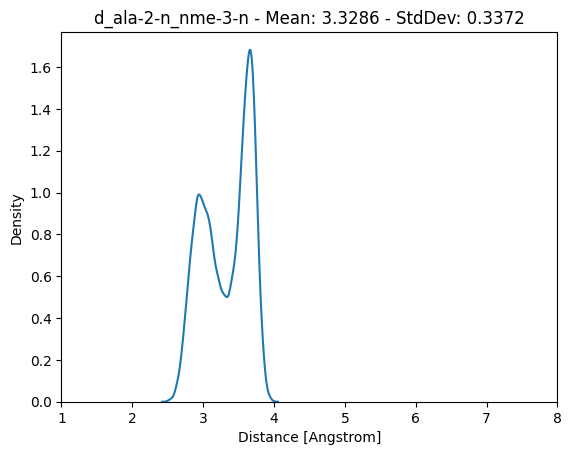

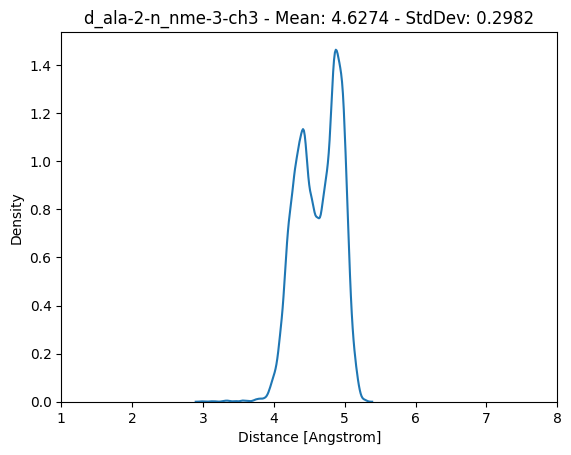

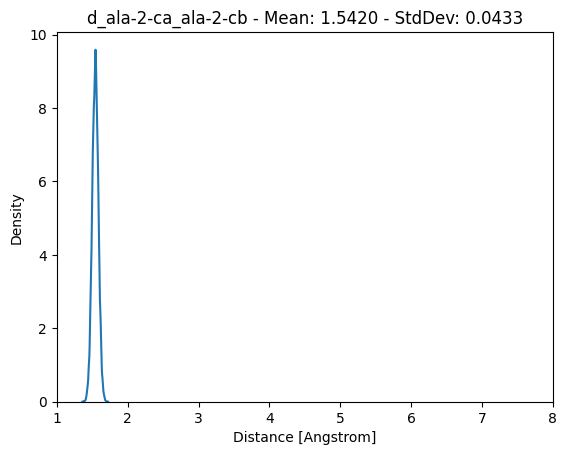

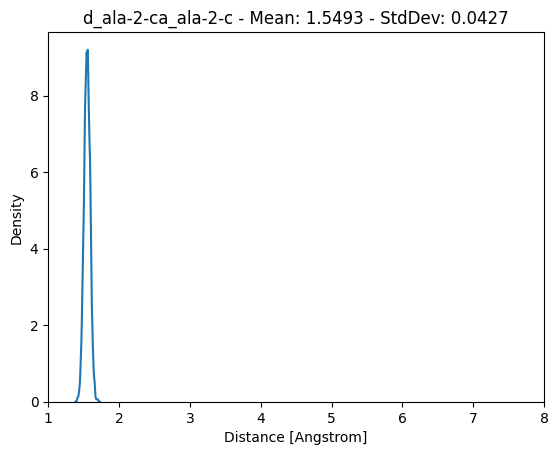

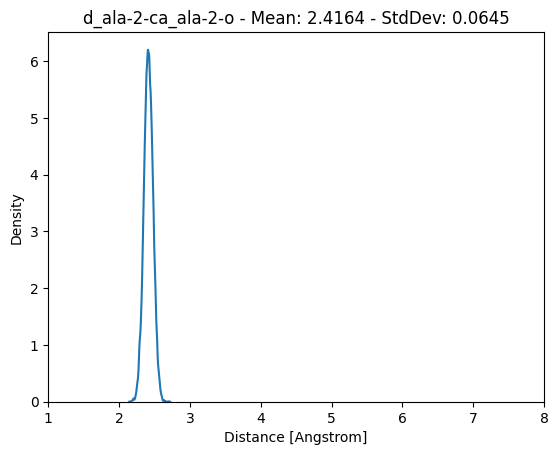

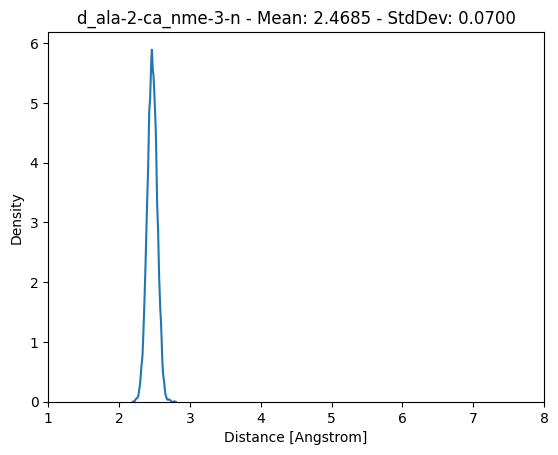

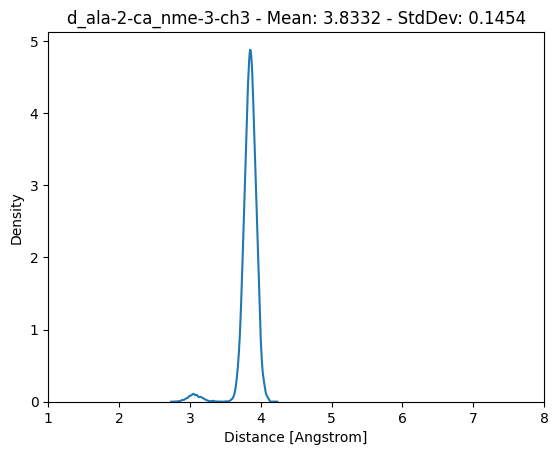

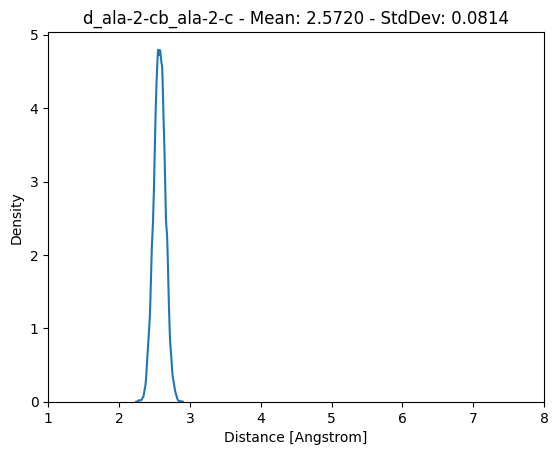

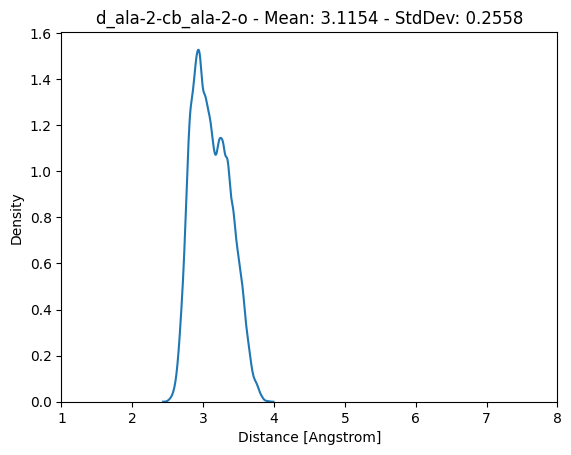

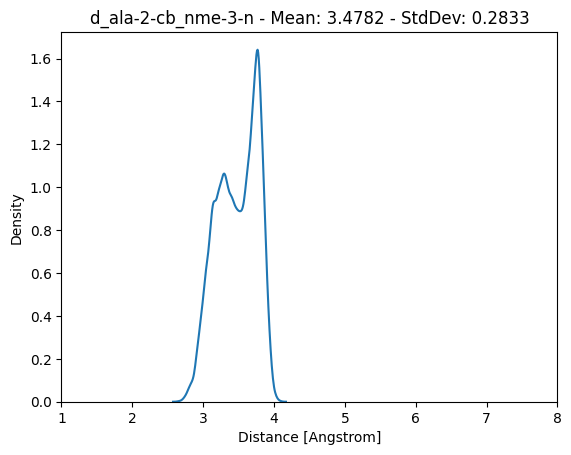

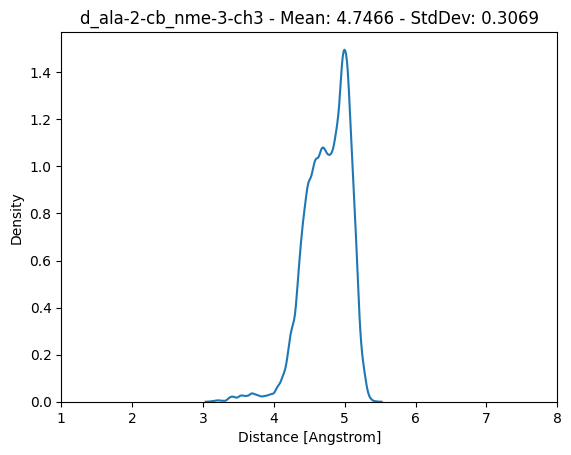

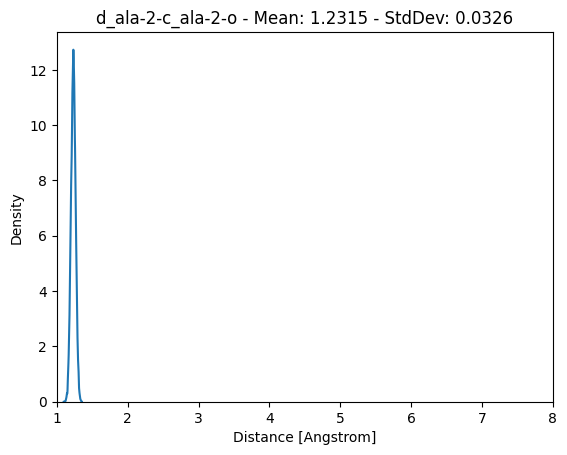

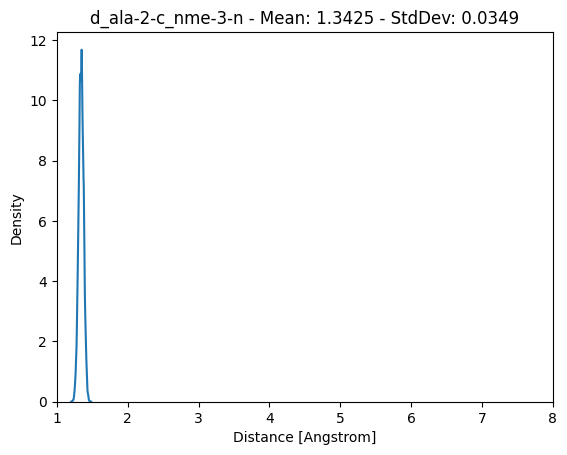

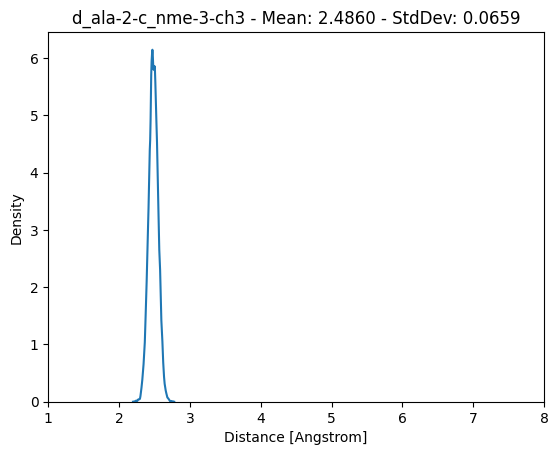

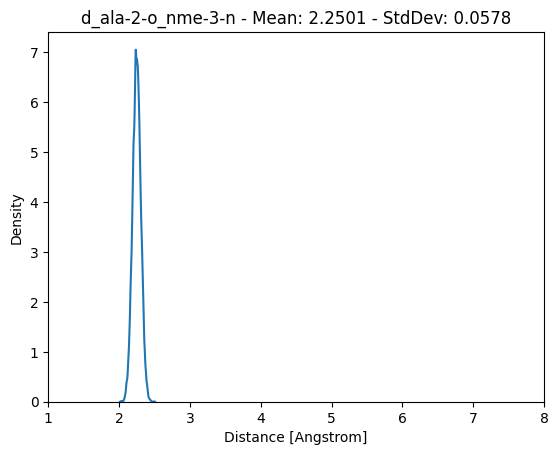

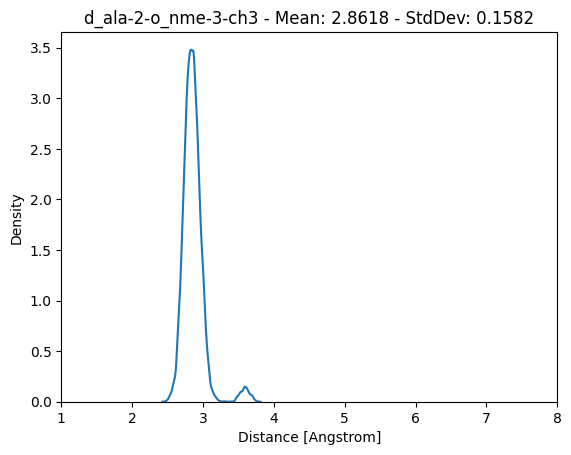

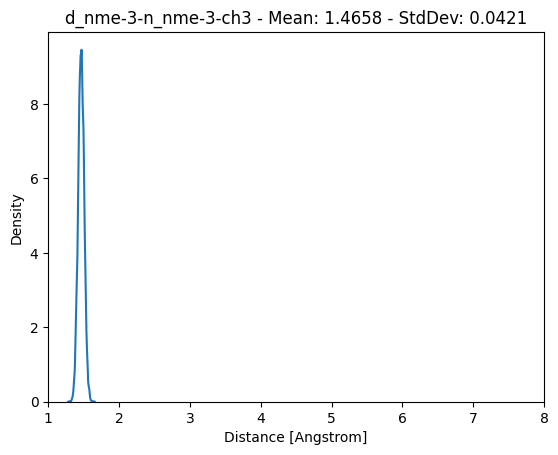

In [33]:
for d in dist_variables[1:]:
  sns.kdeplot(data_dist[d]*10,bw_adjust=0.6)
  plt.xlabel("Distance [Angstrom]")
  plt.ylabel("Density")
  mean = np.mean(data_dist[d]*10)
  sd = np.std(data_dist[d]*10)
  plt.title(d + " - Mean: {:.4f} - StdDev: {:.4f}".format(mean,sd))
  plt.xlim([1,8])
  plt.show()

In [23]:
data_dist.describe()

,time,d_ace-1-ch3_ace-1-c,d_ace-1-ch3_ace-1-o,d_ace-1-ch3_ala-2-n,d_ace-1-ch3_ala-2-ca,d_ace-1-ch3_ala-2-cb,d_ace-1-ch3_ala-2-c,d_ace-1-ch3_ala-2-o,d_ace-1-ch3_nme-3-n,d_ace-1-ch3_nme-3-ch3,...,d_ala-2-cb_ala-2-c,d_ala-2-cb_ala-2-o,d_ala-2-cb_nme-3-n,d_ala-2-cb_nme-3-ch3,d_ala-2-c_ala-2-o,d_ala-2-c_nme-3-n,d_ala-2-c_nme-3-ch3,d_ala-2-o_nme-3-n,d_ala-2-o_nme-3-ch3,d_nme-3-n_nme-3-ch3
count,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,...,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000
mean,50000.002375,0.151455,0.237259,0.242567,0.380870,0.467083,0.464962,0.515988,0.519327,0.631786,...,0.257196,0.311537,0.347815,0.474657,0.123149,0.134246,0.248600,0.225008,0.286177,0.146580
std,28871.844922,0.004307,0.006585,0.007063,0.010477,0.019200,0.020839,0.052842,0.064780,0.067935,...,0.008141,0.025586,0.028328,0.030693,0.003256,0.003494,0.006593,0.005782,0.015817,0.004209
min,0.000000,0.134425,0.213074,0.218553,0.276649,0.338896,0.307994,0.320754,0.313616,0.390436,...,0.226412,0.250772,0.265647,0.312529,0.110609,0.121156,0.221644,0.202937,0.247327,0.129550
25%,25000.001187,0.148535,0.232838,0.237694,0.375955,0.455611,0.453399,0.475071,0.460763,0.574559,...,0.251730,0.290842,0.324634,0.454445,0.120948,0.131920,0.244177,0.221100,0.277092,0.143762
50%,50000.002375,0.151496,0.237288,0.242588,0.381577,0.469078,0.467216,0.509361,0.520008,0.628153,...,0.257231,0.308826,0.350352,0.478263,0.123171,0.134260,0.248540,0.224978,0.284446,0.146574
75%,75000.003562,0.154311,0.241600,0.247367,0.386818,0.480673,0.478912,0.565337,0.580533,0.694148,...,0.262678,0.330943,0.373129,0.498819,0.125360,0.136614,0.253002,0.228850,0.292213,0.149443
max,100000.004750,0.167517,0.260902,0.270317,0.409653,0.522358,0.524818,0.632449,0.643079,0.770313,...,0.287761,0.391888,0.408826,0.543278,0.134314,0.147386,0.275970,0.249213,0.376813,0.164394


In [24]:
stddev = []
for d in dist_variables[1:]:
  sd = np.std(data_dist[d]*10)
  stddev.append(sd)


<Axes: ylabel='Density'>

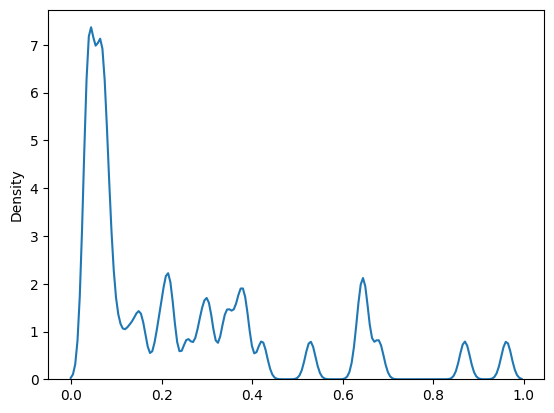

In [30]:
sns.kdeplot(stddev,bw_adjust=0.1)

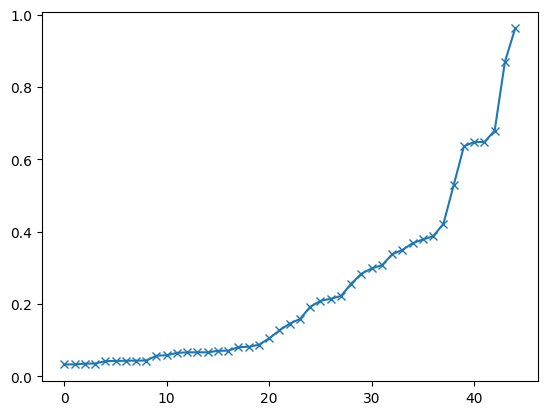

In [51]:
plt.plot(np.sort(stddev),'x-')

In [35]:
dih_variables = get_variables_names_from_header("AlanineDipeptide_T-576K_Dihedrals.data")
data_dih = pd.read_csv("AlanineDipeptide_T-576K_Dihedrals.data", header=None, names=dih_variables, sep="\\s+", comment="#")

# only take every N-th value
stride = 1
data_dist = data_dist.iloc[::stride]
# this is to reset the index
data_dist.reset_index(drop=True, inplace=True)

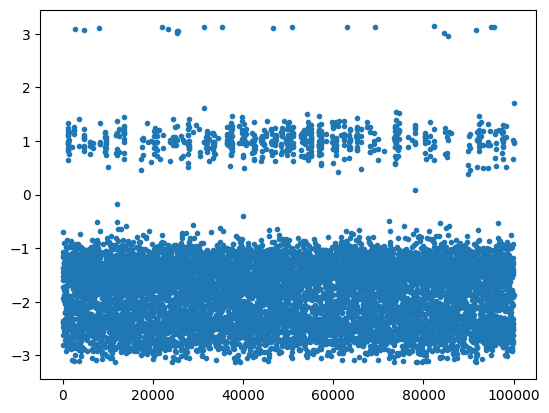

In [48]:
plt.plot(data_dih['time'],data_dih['phi'],'.')
plt.show()